# Задания для практических занятий и самостоятельной работы к главе 2

## Вариант 1

## Уравнение: (0,2x)^3 = cos x

### Задание 1:
### Отделить корни заданного уравнения, пользуясь графическим методом

In [33]:
from numpy import *
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

Графический метод
Уравнение: (0.2x)^3 = cos(x)


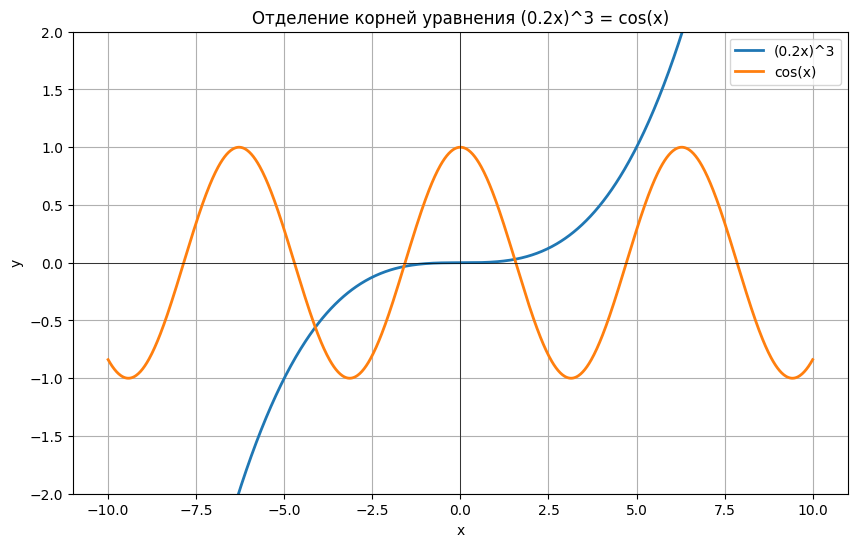


Интервалы, содержащие корни:
----------------------------------------
Корень на [-4.13; -4.11]
Корень на [-1.61; -1.59]
Корень на [1.53; 1.55]


In [34]:
print("Графический метод")
print("Уравнение: (0.2x)^3 = cos(x)")

# Задаем диапазон x
x = linspace(-10, 10, 1000)

y1 = (0.2 * x)**3 # левая часть
y2 = cos(x) # правая часть

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='(0.2x)^3', linewidth=2)
plt.plot(x, y2, label='cos(x)', linewidth=2)
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения (0.2x)^3 = cos(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.ylim(-2, 2) # Ограничиваем ось y для наглядности
plt.show()

# Находим интервалы, где функции пересекаются
print("\nИнтервалы, содержащие корни:")
print("-" * 40)
for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        print(f"Корень на [{x[i]:.2f}; {x[i+1]:.2f}]")

### Задание 2:
### По методу половинного деления вычислить один корень заданного уравнения с точностью 10^-3

In [35]:
print("Метод половинного деления")
def f(x):
    return (0.2 * x)**3 - cos(x)

# Задаем интервал, содержащий первый положительный корень
a, b, eps = 1.0, 2.0, 0.001

while b - a > eps:
    c = (a + b) / 2
    if f(a) * f(c) <= 0:
        b = c
    else:
        a = c

print(f"Корень: {(a + b) / 2:.3f}")

Метод половинного деления
Корень: 1.542


### Задание 3:
### Используя метод простой итерации вычислить один корень заданного уравнения с точностью 10^-6

In [36]:
print("Метод простой итерации")
def f(x):
    return (0.2 * x)**3 - cos(x)

# Приводим к виду x = phi(x) для сходимости метода
def phi(x):
    val = (0.2 * x)**3
    # Ограничитель области определения arccos во избежание ошибок при больших x
    if val > 1: val = 1
    if val < -1: val = -1
    return acos(val)

# Начальное приближение (середина отрезка [1.0, 2.0])
x0, eps = 1.5, 1e-6

while True:
    x1 = phi(x0)
    if abs(x1 - x0) < eps:
        break
    x0 = x1

print(f"Корень: {x1:.6f}")

Метод простой итерации
Корень: 1.541489


### Задание 4:
### Вычислить один корень заданного уравнения используя комбинированный метод хорд и касательных с точностью 10^-6

Уравнение: (0.2x)^3 = cos(x)
Интервал: [1.0, 2.0], точность: 1e-06
------------------------------------------------------------
Итерация   x (середина)    f(x)            |x_i - x_i-1|  
------------------------------------------------------------
1          1.524070        -0.018388       0.024070       
2          1.532004        -0.010017       0.007934       
3          1.531976        -0.010047       0.000028       
4          1.531976        -0.010047       0.000000       
------------------------------------------------------------
КОРЕНЬ: x = 1.531976
Количество итераций: 4
Значение функции: f(x) = -1.00e-02

РЕЗУЛЬТАТ:
  Корень уравнения: x = 1.531976
  Проверка: (0.2x)^3 = 0.028764
            cos(x)   = 0.038811
  Разность: -1.00e-02


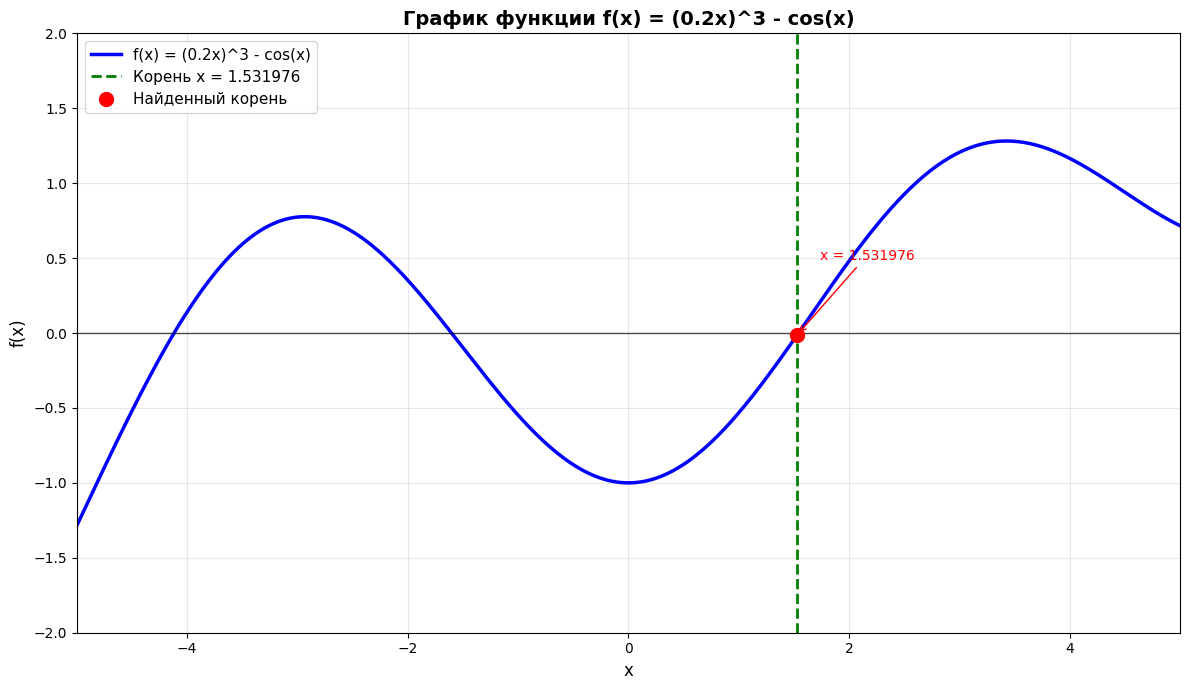

In [37]:
# Определяем функцию и её производную
def f(x):
    return (0.2 * x)**3 - cos(x)

def f_prime(x):
    """Производная: f'(x) = 3*(0.2)^3*x^2 + sin(x) = 0.024*x^2 + sin(x)"""
    return 0.024 * x**2 + sin(x)

# Комбинированный метод хорд и касательных
def find_root(a, b, eps=1e-6, max_iter=50):
    print(f"Уравнение: (0.2x)^3 = cos(x)")
    print(f"Интервал: [{a}, {b}], точность: {eps}")
    print("-" * 60)
    print(f"{'Итерация':<10} {'x (середина)':<15} {'f(x)':<15} {'|x_i - x_i-1|':<15}")
    print("-" * 60)
    
    x_prev = (a + b) / 2  # Начальное приближение
    
    for i in range(max_iter):
        # Метод хорд (секущих)
        if abs(f(b) - f(a)) < 1e-12:
            print("Ошибка: разность значений функции слишком мала")
            return None, i
        x_chord = a - f(a) * (b - a) / (f(b) - f(a))
        
        # Метод касательных (Ньютона)
        if f(a) * f_prime(a) > 0:
            if abs(f_prime(a)) < 1e-12:
                return None, i
            x_tangent = a - f(a) / f_prime(a)
        else:
            if abs(f_prime(b)) < 1e-12:
                return None, i
            x_tangent = b - f(b) / f_prime(b)
        
        # Комбинированный метод - берём среднее
        x = (x_chord + x_tangent) / 2
        
        # Проверка сходимости
        diff = abs(x - x_prev)
        print(f"{i+1:<10} {x:<15.6f} {f(x):<15.6f} {diff:<15.6f}")
        
        if abs(f(x)) < eps or diff < eps:
            print("-" * 60)
            print(f"КОРЕНЬ: x = {x:.6f}")
            print(f"Количество итераций: {i+1}")
            print(f"Значение функции: f(x) = {f(x):.2e}")
            return x, i+1
        
        # Сужаем интервал
        if f(a) * f(x) < 0:
            b = x
        else:
            a = x
        
        x_prev = x
    
    return (a + b) / 2, max_iter

# Основная программа
if __name__ == "__main__":
    a, b = 1.0, 2.0
    
    root, iterations = find_root(a, b, eps=1e-6)
    
    if root is not None:
        print(f"\nРЕЗУЛЬТАТ:")
        print(f"  Корень уравнения: x = {root:.6f}")
        print(f"  Проверка: (0.2x)^3 = {(0.2 * root)**3:.6f}")
        print(f"            cos(x)   = {math.cos(root):.6f}")
        print(f"  Разность: {f(root):.2e}")
    
    # Создаем массив точек для графика
    x_vals = linspace(-5.0, 5.0, 500)
    y_vals = [(0.2 * xi)**3 - cos(xi) for xi in x_vals]
    
    plt.figure(figsize=(12, 7))
    plt.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='f(x) = (0.2x)^3 - cos(x)')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    
    if root is not None:
        plt.axvline(x=root, color='green', linestyle='--', linewidth=2, label=f'Корень x = {root:.6f}')
        plt.plot(root, f(root), 'ro', markersize=10, label='Найденный корень')
        
        plt.annotate(f'x = {root:.6f}', 
                    xy=(root, f(root)), 
                    xytext=(root + 0.2, f(root) + 0.5),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10, color='red')
    
    plt.grid(True, alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.title('График функции f(x) = (0.2x)^3 - cos(x)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='upper left')
    plt.xlim(-5.0, 5.0)
    plt.ylim(-2, 2)
    plt.tight_layout()
    plt.show()

### Задание 5:
### Вычислить один корень заданного уравнения с помощью инструментального пакета (SciPy) и точностью 10^-6

Уравнение: (0.2x)^3 = cos(x)
Интервал: [1.0, 2.0], точность: 1e-06

Метод: brentq
Корень найден: x = 1.541489
Значение функции: f(x) = -1.06e-07
Количество итераций: 5
Сходимость: converged
РЕЗУЛЬТАТ:
  Корень уравнения: x = 1.541489
  Проверка: (0.2x)^3 = 0.029303
            cos(x)   = 0.029303
  Разность: -1.06e-07


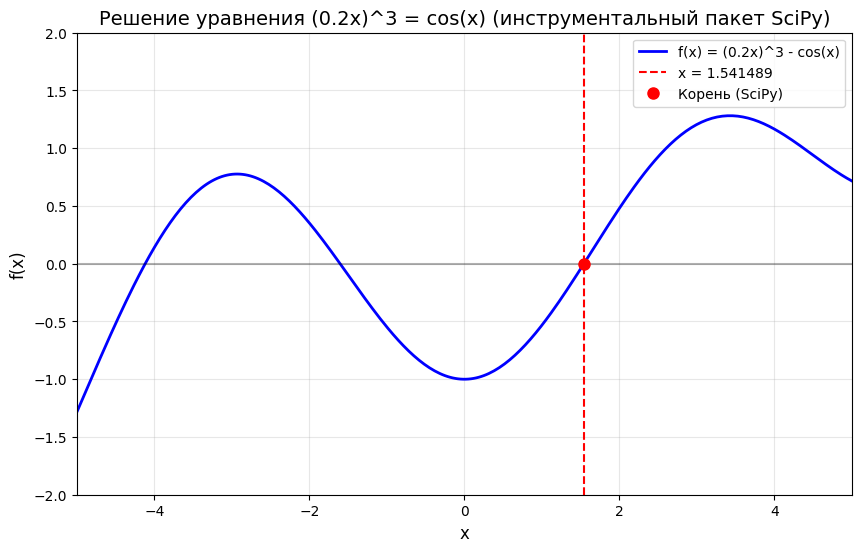

In [38]:
def f(x): 
    return (0.2 * x)**3 - cos(x)

def solve_with_scipy(a, b, eps=1e-6):
    print(f"Уравнение: (0.2x)^3 = cos(x)")
    print(f"Интервал: [{a}, {b}], точность: {eps}\n")
    
    sol = root_scalar(f, bracket=[a, b], method='brentq', xtol=eps, rtol=eps)
    
    if sol.converged:
        print(f"Метод: {sol.method}")
        print(f"Корень найден: x = {sol.root:.6f}")
        if hasattr(sol, 'function_value'):
            print(f"Значение функции: f(x) = {sol.function_value:.2e}")
        elif hasattr(sol, 'f'):
            print(f"Значение функции: f(x) = {sol.f:.2e}")
        else:
            print(f"Значение функции: f(x) = {f(sol.root):.2e}")
        
        if hasattr(sol, 'iterations'):
            print(f"Количество итераций: {sol.iterations}")
        else:
            print("Количество итераций: не указано")
            
        print(f"Сходимость: {sol.flag}")
        return sol.root, getattr(sol, 'iterations', 0)
    else:
        print("Решение не сошлось")
        return None, 0

interval_start = 1.0
interval_end = 2.0
eps = 1e-6

root, iterations = solve_with_scipy(interval_start, interval_end, eps)

if root is not None:
    print("РЕЗУЛЬТАТ:")
    print(f"  Корень уравнения: x = {root:.6f}")
    print(f"  Проверка: (0.2x)^3 = {(0.2 * root)**3:.6f}")
    print(f"            cos(x)   = {cos(root):.6f}")
    print(f"  Разность: {f(root):.2e}")

x_vals = linspace(-5.0, 5.0, 300)
y_vals = [(0.2 * xi)**3 - cos(xi) for xi in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = (0.2x)^3 - cos(x)')
plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=root, color='r', linestyle='--', label=f'x = {root:.6f}')
plt.plot(root, f(root), 'ro', markersize=8, label='Корень (SciPy)')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Решение уравнения (0.2x)^3 = cos(x) (инструментальный пакет SciPy)', fontsize=14)
plt.legend(fontsize=10)
plt.xlim(-5.0, 5.0)
plt.ylim(-2, 2)
plt.show()